In [1]:
# Autoreload
%load_ext autoreload
%autoreload 2

from optimizer import Optimizer
from chromosome import Chromosome
from character import Character
from utils import get_item_set, elements
import json

with open('data/MAPPED_ITEMS.json', 'r') as file:
    items = {i["ankama_id"]: i for i in json.load(file)}

with open('data/MAPPED_SETS.json', 'r') as file:
    item_sets = {i["ankama_id"]: i for i in json.load(file)}

In [2]:
config = {
            "optimizer" : {
                "language": "es",
                "population_size": 300,
                "num_parents_mating": 100, # Number of parents to mate, usually 1/3 of population size
                "num_generations": 400,
                "mutation_rate": 0.05,
                "crossover_rate": 0.8,
                "parent_selection_type": "tournament",  # Tournament Selection
                "tournament_size": 3,
                "exclusions": {
                    "items": [6894,
                              6895,
                              3080,
                              9031,
                              8575, # Ramboton
                              6980, # Vulbis
                              7754, # Dofus ocre
                              13344, # Dolmanax
                              ]  # Excluded items
                },
                "inclusions": {
                    "items": [
                    ]
                },
                "preferences": {
                    "lower": {
                        12: {
                            "target": 12,  # AP
                            "strength": 0.9,  # Penalty for not meeting the target
                        },
                        8: {
                            "target": 5,  # MP
                            "strength": 0.9,  # Penalty for not meeting the target
                        },
                        29: {
                            "target": 75,  # Crit
                            "strength": 0.75,  # Penalty for not meeting the target
                        },
                        9: {
                            "target": 4000,  # Vit
                            "strength": 0.5,  # Penalty for not meeting the target
                        },
                        34 : {
                            "target": 15, # %res neutral
                            "strength": 0.1,  # Penalty for not meeting the target
                        },
                        37 : {
                            "target": 15, # %res fire
                            "strength": 0.1,  # Penalty for not meeting the target
                        },
                        16 : {
                            "target": 15, # %res air
                            "strength": 0.1,  # Penalty for not meeting the target
                        },
                        17 : {
                            "target": 15, # %res water
                            "strength": 0.1,  # Penalty for not meeting the target
                        },
                        63 : {
                            "target": 15, # %res range
                            "strength": 0.1,  # Penalty for not meeting the target
                        },
                        # 31 : {
                        #     "target": 6, # alcance
                        #     "strength": 0.75,  # Penalty for not meeting the target
                        # }
                    },
                    "upper": {}
                },
                "level_offset": 10,  # Level offset for items
                "objective": "weapon"  # Objective to optimize, can be "weapon" or "elements"
            },
            "character": {
                "level": 200,
                "scrolled": True,
                "exo": {
                    12:1, # Exo AP
                    # 8:1,  # Exo MP
                    },
                "distributed_points": {
                    # 9: 995,  # Vitality
                },
                "elements" : [
                    36, # Agility,
                    22, # Chance
                    13, # Intelligence
                    45  # Strength
                ],
                "melee" : False,
                "ranged" : 3 # True or minimum range 
            },
        }

In [3]:
import pandas as pd
dct = {}
for k,v in items.items():
    item_set = get_item_set(v,item_sets)
    dct[k] = {
        "name" : v["name"][config["optimizer"]["language"]],
        "set" : item_set["name"][config["optimizer"]["language"]] if item_set else None,
        "level" : v["level"]
    }
Items = pd.DataFrame.from_dict(dct, orient='index')
# Exclude items from the Gargandias set
config["optimizer"]["exclusions"]["items"] += Items[Items["set"].str.contains("Set de Gargandias",na=False,case=False)].index.tolist()

In [4]:
Items[Items["name"].str.contains("casco de miau", case=False)]

,name,set,level
17579,Casco de Miauvizor,Set de Miauvizor,200


In [5]:
char = Character(**config["character"])
opt = Optimizer(char,
                 items,
                   item_sets,
                     **config["optimizer"])

Total items: 2652
Total item sets: 147
Total pools:
   16 with sizes [68, 26, 71, 71, 62, 81, 39, 88, 69, 412, 324, 324, 324, 324, 324, 324]
Total combinations: 10^33.70


In [ ]:
solutions = opt.optimize(islands = 10, max_workers = 4)

/Users/jdtibochab/miniconda3/envs/optimization/lib/python3.10/site-packages/pygad/pygad.py:1149: UserWarning: Use the 'save_best_solutions' parameter with caution as it may cause memory overflow when either the number of generations or number of genes is large.
  warnings.warn("Use the 'save_best_solutions' parameter with caution as it may cause memory overflow when either the number of generations or number of genes is large.")
/Users/jdtibochab/miniconda3/envs/optimization/lib/python3.10/site-packages/pygad/pygad.py:1149: UserWarning: Use the 'save_best_solutions' parameter with caution as it may cause memory overflow when either the number of generations or number of genes is large.
  warnings.warn("Use the 'save_best_solutions' parameter with caution as it may cause memory overflow when either the number of generations or number of genes is large.")
/Users/jdtibochab/miniconda3/envs/optimization/lib/python3.10/site-packages/pygad/pygad.py:1149: UserWarning: Use the 'save_best_solut

## Analysis

In [ ]:
from analysis import Analyzer
analyzer = Analyzer(opt, solutions)
analyzer.run_analysis()

Number of candidate solutions: 96


In [ ]:
analyzer.report_extended_results()

Solution 0:
	Fitness: 307.2305
	Weapon damage: 1228.922
		Weapon: Varita Liana
		AP Cost: 4
		Casts per turn: 1
	Spell damage: 1229.7825
	Preferences:
		PA : 11.0
		PM : 5.0
		% crítico : 78.0
		vitalidad : 4050.0
		% resistencia neutral : 17.0
		% resistencia al fuego : 17.0
		% resistencia al aire : 41.0
		% resistencia al agua : 28.0
		% resistencia a la tierra : 26.0
	Characteristics:
		agilidad: 100.0
		suerte: 535.0
		inteligencia: 405.0
		fuerza: 560.0
		vitalidad: 4050.0
		sabiduría: 385.0
	Items:
		Type	Description	Level
		Amuleto	Amuleto de estrígido	200
		Anillo	Anillo de Corrupción	200
		Anillo	Alianza de Corrupción	200
		Bota	Botas de la reina del azar	200
		Capa	Capa Pología	198
		Cinturón	Cintáceo	200
		Dofus	Dofus Púrpura	110
		Dofus	Dofus Turquesa	160
		Dofus	Dofus de los hielos	180
		Escudo	Cuadrifolio	193
		Mascota	Lokulto	20
		Sombrero	Kidiboina	200
		Trofeo	Asolador de agua mayor	150
		Trofeo	Lozano mayor	150
		Trofeo	Espabilador	100
		Varita	Varita Liana	193


Sol

In [ ]:
analyzer.report_extended_results()

Solution 0:
	Fitness: 307.2305
	Weapon damage: 1228.922
		Weapon: Varita Liana
		AP Cost: 4
		Casts per turn: 1
	Spell damage: 1229.7825
	Preferences:
		PA : 11.0
		PM : 5.0
		% crítico : 78.0
		vitalidad : 4050.0
		% resistencia neutral : 17.0
		% resistencia al fuego : 17.0
		% resistencia al aire : 41.0
		% resistencia al agua : 28.0
		% resistencia a la tierra : 26.0
	Characteristics:
		agilidad: 100.0
		suerte: 535.0
		inteligencia: 405.0
		fuerza: 560.0
		vitalidad: 4050.0
		sabiduría: 385.0
	Items:
		Type	Description	Level
		Amuleto	Amuleto de estrígido	200
		Anillo	Anillo de Corrupción	200
		Anillo	Alianza de Corrupción	200
		Bota	Botas de la reina del azar	200
		Capa	Capa Pología	198
		Cinturón	Cintáceo	200
		Dofus	Dofus Púrpura	110
		Dofus	Dofus Turquesa	160
		Dofus	Dofus de los hielos	180
		Escudo	Cuadrifolio	193
		Mascota	Lokulto	20
		Sombrero	Kidiboina	200
		Trofeo	Asolador de agua mayor	150
		Trofeo	Lozano mayor	150
		Trofeo	Espabilador	100
		Varita	Varita Liana	193


Sol

In [ ]:
analyzer.plot_pca()

NameError: name 'analyzer' is not defined

In [ ]:
candidate = analyzer.candidates[0]
analyzer.report_results([candidate])
candidate.totals_summary()

Solution 0:
	Fitness: 259.47749999999996
	Weapon damage: 1037.9099999999999
		Weapon: Varita Liana
		AP Cost: 4
		Casts per turn: 1
	Spell damage: 1034.44
	Preferences:
		PA : 11.0
		PM : 5.0
		% crítico : 76.0
		vitalidad : 4100.0
		% resistencia neutral : 27.0
		% resistencia al fuego : 17.0
		% resistencia al aire : 35.0
		% resistencia al agua : 54.0
		% resistencia a la tierra : 28.0
	Characteristics:
		agilidad: 160.0
		suerte: 475.0
		inteligencia: 335.0
		fuerza: 470.0
		vitalidad: 4100.0
		sabiduría: 395.0
	Items:
		Type	Description	Level
		Amuleto	Amuleto de Wulán	200
		Anillo	Anillo del profesor Xa	191
		Anillo	Anillo de Corrupción	200
		Bota	Ballenotas	200
		Capa	Capa de Anerice	200
		Cinturón	Cintáceo	200
		Dofus	Dofus Púrpura	110
		Dofus	Dofus Turquesa	160
		Dofus	Dofus de los hielos	180
		Escudo	Cuadrifolio	193
		Mascota	Lokulto	20
		Sombrero	Máscara de Anerice	200
		Trofeo	Asolador de agua mayor	150
		Trofeo	Lozano mayor	150
		Trofeo	Espabilador	100
		Varita	Varita Lian

,description,value
0,Intercambiable:,0.0
8,PM,5.0
9,vitalidad,4100.0
10,sabiduría,395.0
12,PA,11.0
13,inteligencia,335.0
16,% resistencia al aire,35.0
17,% resistencia al agua,54.0
22,suerte,475.0
24,iniciativa,400.0


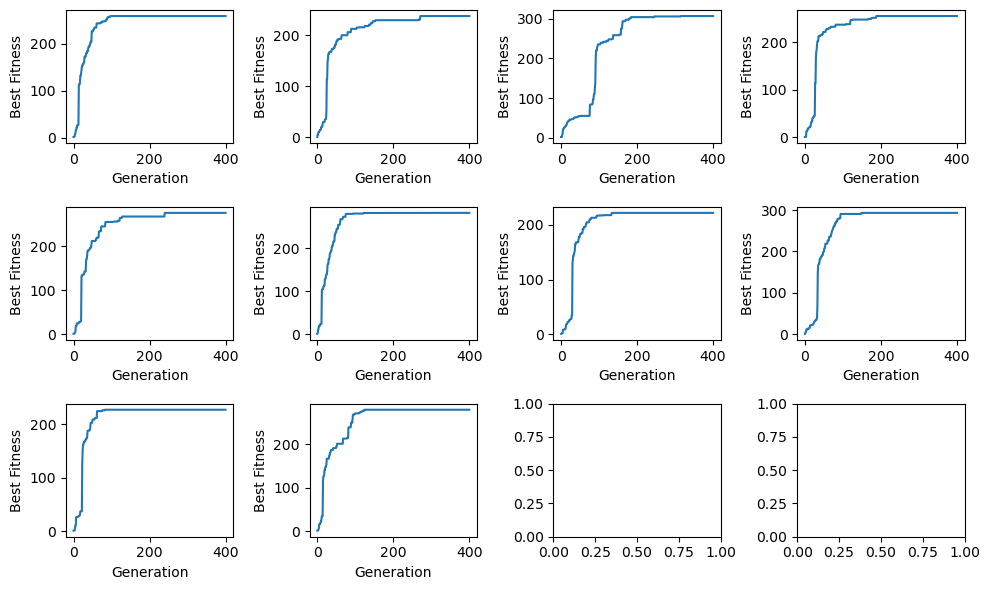

In [ ]:
analyzer.report_generations()

In [ ]:
assert False

AssertionError: 

In [ ]:
tmp = candidate.chromosome
tmp[1] = 15779
chr = Chromosome(tmp, opt)
chr.fitness

68.22342

In [ ]:
# Current
chr = Chromosome([
                    8993, # Espada
                    13641, 13643, 13642, # Noai
                    14161, 14162, 14169, # Charlatan
                    19985, # Vuelo
                    18670, # Escudo
                    13673, # Lokulto
                    739, 694, 7754, 737, 7043, 17078 # Dofus
                 ],
                 opt)
chr.fitness

1890.67

In [ ]:
Items[Items["name"].str.contains("kuko")]

,name,set,level
13989,Pluma de kukoloide,None,200
14091,Amuleto de kukoloide,Set de kukoloide,200
14092,Anillo de kukoloide,Set de kukoloide,200
14093,Botas de kukoloide,Set de kukoloide,200
13988,Ojo de kukoloide,None,200
18718,Escudo de kukoloide,Set de kukoloide,200


In [ ]:
# Project
chr = Chromosome(
                 [
                    8993, # Espada
                    13641, 13642, # Noai
                    14161, 14162, 14169, # Charlatan
                    14092, 14093, 18718, # Kuko
                    13673, # Lokulto
                    739, 694, 7754, 737, 7043, 17078 # Dofus
                 ],
                 opt)
chr.fitness

2049.74

In [ ]:
chr.set_summary()

In [ ]:
chr.set_summary()["set"].value_counts()

In [ ]:
chr.totals_summary(effect_descriptions)

In [ ]:
Items[Items["name"].str.contains("Chani")]

In [ ]:
item = items[21392]
# item = items[6981]

In [ ]:
chr.are_item_conditions_met(item)

In [ ]:
item

In [ ]:
Items

In [ ]:
lst

In [ ]:
lst[0][2]

In [ ]:
chr.are_item_conditions_met(items[11738])

In [ ]:
items[11738]["conditions"]

In [ ]:
chr.totals[8]

In [ ]:
lst = []
for i in items.values():
    if i["type"]["superTypeId"] not in [i[0] for i in opt.pool_types]:
        continue
    if i["conditions"]:
        print(opt.solution.are_item_conditions_met(i))
        lst.append((i,opt.solution.are_item_conditions_met(i)))

In [ ]:
lst[1]

In [ ]:
lst.count(True), lst.count(False)